# Data Exploration

In [5]:
import os, sys
sys.path.append(os.path.abspath(".."))

import torch
from src.data import createDataset

torch.manual_seed(42)

train_dataset = createDataset('../dataset/train')
val_dataset = createDataset('../dataset/val')

print(f"Length of train dataset: {len(train_dataset)}")
print(f"Length of validation dataset: {len(val_dataset)}")

Length of train dataset: 4480
Length of validation dataset: 1120


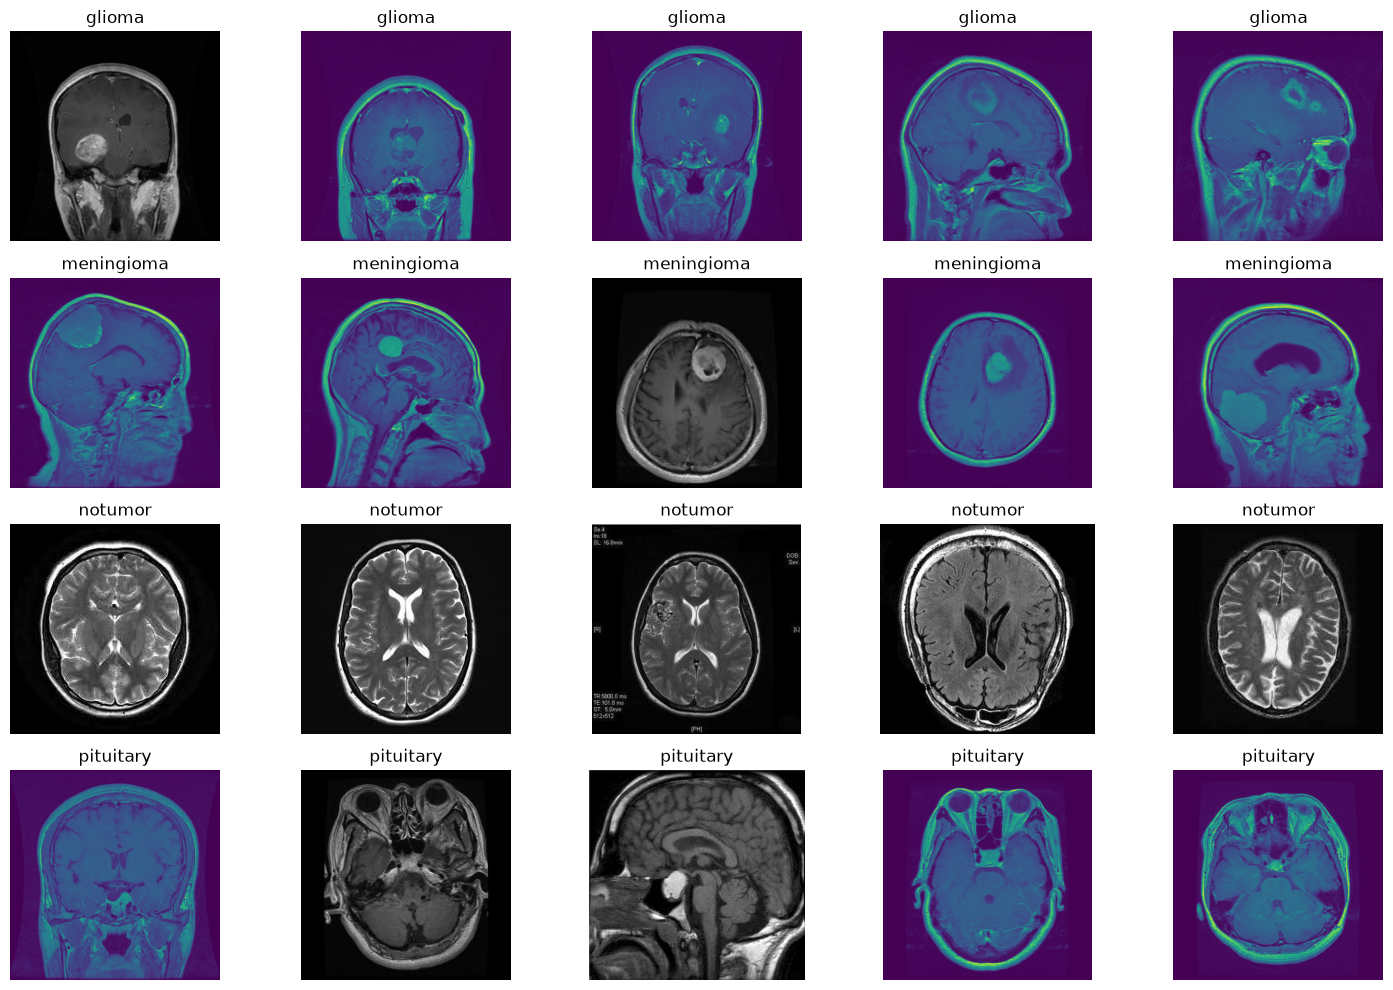

In [6]:
import os
import random
from PIL import Image
import matplotlib.pyplot as plt

train_dir = "../dataset/train"

classes = sorted([
    class_name
    for class_name in os.listdir(train_dir)
    if os.path.isdir(os.path.join(train_dir, class_name))
])

random.seed(42)

fig, axes = plt.subplots(
    len(classes),
    5,
    figsize=(15, 10)
)

for row, class_name in enumerate(classes):
    class_path = os.path.join(train_dir, class_name)

    images = [
        file
        for file in os.listdir(class_path)
        if os.path.isfile(os.path.join(class_path, file))
    ]

    selected_images = random.sample(images, 5)

    for col, image_name in enumerate(selected_images):
        image_path = os.path.join(class_path, image_name)
        image = Image.open(image_path)

        axes[row, col].imshow(image)
        axes[row, col].set_title(class_name)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

In [7]:
from PIL import Image
from collections import Counter
import os

dimensions = Counter()
modes = Counter()

for split in ["train", "val", "test"]:
    split_path = os.path.join('../dataset', split)

    for class_name in os.listdir(split_path):
        class_path = os.path.join(split_path, class_name)

        if not os.path.isdir(class_path):
            continue

        for image_name in os.listdir(class_path):
            image_path = os.path.join(class_path, image_name)

            if not os.path.isfile(image_path):
                continue

            try:
                with Image.open(image_path) as image:
                    dimensions[image.size] += 1
                    modes[image.mode] += 1

            except Exception:
                pass

print("Image dimensions:")
for dimension, count in dimensions.most_common():
    print(f"{dimension}: {count}")

print("\nImage modes:")
for mode, count in modes.most_common():
    print(f"{mode}: {count}")

Image dimensions:
(512, 512): 5014
(225, 225): 338
(630, 630): 90
(201, 251): 57
(228, 221): 51
(232, 217): 50
(442, 442): 48
(236, 236): 48
(150, 198): 44
(200, 252): 43
(428, 417): 42
(227, 222): 39
(173, 201): 36
(206, 244): 35
(256, 256): 33
(192, 192): 31
(201, 250): 29
(218, 231): 29
(215, 234): 28
(227, 262): 27
(468, 444): 24
(208, 242): 24
(504, 540): 23
(359, 449): 23
(214, 236): 22
(300, 168): 21
(400, 442): 20
(236, 213): 19
(393, 400): 18
(207, 243): 18
(442, 454): 17
(230, 282): 17
(276, 326): 17
(441, 442): 16
(235, 214): 16
(550, 664): 16
(194, 259): 15
(680, 680): 15
(420, 280): 14
(339, 340): 13
(212, 238): 12
(275, 183): 12
(642, 361): 12
(196, 257): 12
(380, 530): 12
(350, 350): 11
(177, 197): 9
(356, 474): 9
(350, 393): 7
(554, 554): 6
(455, 500): 5
(236, 357): 5
(1024, 1024): 5
(235, 227): 5
(208, 248): 5
(220, 275): 5
(200, 223): 4
(341, 395): 4
(212, 237): 4
(275, 301): 4
(416, 512): 4
(236, 269): 4
(201, 210): 4
(210, 240): 4
(213, 237): 3
(236, 295): 3
(236, 2